<a href="https://colab.research.google.com/gist/francischisom/34eabe1bf3b7bb3eb50c9eec34a3c62b/explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainability & Agent on Fine-Tuned BioBERT
## The setup: explain the project's strongest model


This notebook wires our **fine-tuned BioBERT** into LIME, SHAP, FAISS, and the
autonomous agent, so every explanation reflects your best model rather than a
baseline. LIME and SHAP run together at the agent's explain step.

**Note Before:**  Use a GPU runtime, and keep
`num_samples` / `max_evals` which are modest for interactive use.


##  Checklist

**REQUIRED FILES** (all in the same folder as this notebook, or in `src/`):
- `eval_utils.py` · `explainability.py` · `case_retrieval.py`
- `ade_agent.py` · `biobert_infer.py` · `xai_visuals.py`

**REQUIRED DATA:** `train.csv`, `val.csv`, `test.csv`, `unified_full.csv`

**REQUIRED MODEL:** our saved fine-tuned BioBERT folder




In [ ]:
# Run ONCE per session; installs the packages the 6 modules needed
!pip install -q pandas numpy scikit-learn transformers torch lime shap faiss-cpu plotly
# Classic kaleido bundles its own Chromium
!pip install -q "kaleido==0.2.1"

# Silence the ipywidgets progress bars
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
try:
    import transformers
    transformers.logging.set_verbosity_error()
    transformers.utils.logging.disable_progress_bar()
except Exception:
    pass

%matplotlib inline

print('Setup ready — now run the cells below in order.')


Setup ready — now run the cells below in order.


##  Setup
Point `MODEL_DIR` at your saved fine-tuned BioBERT directory (the Trainer's
`output_dir`, e.g. `biobert_out`, or wherever you copied the best checkpoint).


In [ ]:

!pip install -q transformers torch lime shap faiss-cpu scikit-learn pandas
# import sys; sys.path.append('src')

import pandas as pd
import eval_utils as ev
import explainability as ex
import case_retrieval as cr
import ade_agent as ag
import biobert_infer as bb

MODEL_DIR = 'biobert_out'      # <-- your saved fine-tuned BioBERT directory
train_df, val_df, test_df, full_df = ev.load_splits(
    'train.csv', 'val.csv', 'test.csv', 'unified_full.csv')


##  Load fine-tuned BioBERT


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Point at your actual folder (you said it's called biobert_model, on Drive)
MODEL_DIR = '/content/drive/MyDrive/biobert_model'

# Verify it's really there and contains a saved model BEFORE loading
import os
assert os.path.isdir(MODEL_DIR), f"Folder not found: {MODEL_DIR}"
print("Folder contents:", os.listdir(MODEL_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder contents: ['biobert_finetune.py', 'config.json', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin', 'model.safetensors']


In [ ]:
biobert = bb.load_biobert(MODEL_DIR, max_len=128)
print('Loaded BioBERT on', biobert.device)

# sanity check: a probability for one example
sample = test_df[ev.RAW_TEXT_COL].iloc[0]
print('P(ADE) =', round(biobert.classify_fn(sample), 3))


Loaded BioBERT on cuda
P(ADE) = 0.001


##  LIME on BioBERT
LIME perturbs the input and queries BioBERT's `predict_proba`. Keep
`num_samples` modest because each sample is a full BioBERT forward pass.


In [ ]:
lime_words = ex.explain_with_lime(
    sample, biobert.predict_proba, num_features=8, num_samples=200)
print('LIME drivers (BioBERT):')
for w, wt in lime_words:
    print(f'  {w:20s} {wt:+.3f}')


LIME drivers (BioBERT):
  relieves             -0.652
  Uses                 -0.197
  soreness             +0.167
  Temporarily          -0.139
  injuries             -0.082
  associated           -0.079
  Muscle               +0.078
  swelling             -0.065


##  SHAP on BioBERT


In [ ]:
shap_words = ex.shap_top_words_for_text(
    sample, biobert.predict_proba, top_k=8, max_evals=120)
print('SHAP drivers (BioBERT):')
for w, wt in shap_words:
    print(f'  {w:20s} {wt:+.4f}')


SHAP drivers (BioBERT):
  relieves             -0.5116
  soreness             +0.3085
  associated           -0.1047
  Muscle               +0.0956
  falls                +0.0877
  Bruises              +0.0793
  injuries             -0.0620
  discoloration        +0.0550


##  FAISS retrieval in BioBERT embedding space
Index the training cases using BioBERT embeddings, so retrieved precedents
are similar in the same representation the model actually uses.


In [ ]:
retriever = cr.CaseRetriever(bb.biobert_embedder(biobert)).build(train_df)
neighbours = retriever.query(sample, k=10)
print(cr.format_neighbours(neighbours))


#1 (sim=0.934) [label=0, severity=none, domain=Formal (DailyMed)]
    use temporarily relief muscle pain stiffness due tominor iniuries overexerion fall reduces symptom bruising aspain sweling discoloration
#2 (sim=0.934) [label=0, severity=none, domain=Formal (DailyMed)]
    use temporarily relief minor pain associated arthritis simple backachebursitis tendonitis muscle strain sprainsbruises cramp
#3 (sim=0.934) [label=0, severity=none, domain=Formal (DailyMed)]
    indication meloxicam oral suspension indicated control pain inflammation associated osteoarthritis dog
#4 (sim=0.928) [label=0, severity=none, domain=Formal (DailyMed)]
    use temporarily relief symptom associated minor bruise includingswelling discolorationtenderness minor soreness due overexertion
#5 (sim=0.928) [label=0, severity=none, domain=Formal (DailyMed)]
    use regrow hair scalp promote beard growth men
#6 (sim=0.921) [label=0, severity=none, domain=Formal (DailyMed)]
    us relief occasional constipation irreg

## The agent on BioBERT (LIME + SHAP together)
Now the agent classifies, routes, and explains entirely on BioBERT.


In [ ]:
severity_fn = lambda t: ('severe' if any(w in t.lower() for w in
    ['severe','emergency','hospital','breathing','swelling','collapsed'])
    else 'moderate' if any(w in t.lower() for w in ['stopped','vomiting','unable'])
    else 'mild')

agent = ag.build_agent(
    classify_fn=biobert.classify_fn,
    retriever=retriever,
    explain_fn=lambda t: ex.explain_with_lime(
        t, biobert.predict_proba, num_features=6, num_samples=150),
    shap_fn=lambda t: ex.shap_top_words_for_text(
        t, biobert.predict_proba, top_k=6, max_evals=100),
    severity_fn=severity_fn,
    confidence_margin=0.15)

result = agent.run(sample)
print(ag.format_trace(result))
print('\nLIME/SHAP agreement:', result.evidence.get('lime_shap_agreement'))


AGENT DECISION: ADE p=0.00 | severity=severe | none -> auto_logged
Rationale: No adverse event detected.

Reasoning trace:
  [1] THINK: I must first estimate ADE probability with the model.
      ACT:   classify(Uses: Temporarily relieves pain, swelling, and dis...)
      OBS:   0.0009073699475266039
  [2] THINK: Model is confident; no extra retrieval needed for the decision.
      ACT:   skip_retrieval(None)
      OBS:   confident
  [3] THINK: Assess severity to inform triage routing.
      ACT:   assess_severity(Uses: Temporarily relieves pain, swelling, and dis...)
      OBS:   severe
  [4] THINK: Combine probability and severity into a routing decision.
      ACT:   triage({'proba': 0.0009073699475266039, 'severity': 'seve...)
      OBS:   {'triage_level': 'none', 'route': 'auto_logged', 'confidence': 0.001, 'rationale': 'No adverse event detected.'}

LIME/SHAP agreement: None


---
##  Research Example: a clinical-triage case

We run the **full BioBERT explainability stack on one real clinical-triage case**,
selected at random from the **held-out test set** using a fixed `random_state` so the
figures are reproducible. The case is real data (de-identified DailyMed/CADEC
text), used here to demonstrate how the system explains and triages a single report
end to end. (It is not live patient data.)


In [ ]:
# !pip install -q plotly
import xai_visuals as xv
import eval_utils as ev
from IPython.display import HTML, display

# Make every Plotly `.show()` below render as a static PNG so the figures
xv.use_static_renderer(scale=2)

# Pick a RANDOM real case from the held-out test set.
positive_only = True
RANDOM_STATE = 42

pool = test_df[test_df[ev.LABEL_COL] == 1] if positive_only else test_df
chosen = pool.sample(n=1, random_state=RANDOM_STATE).iloc[0]

triage_case = chosen[ev.RAW_TEXT_COL]
true_label = 'ADE' if chosen[ev.LABEL_COL] == 1 else 'No ADE'
true_domain = chosen.get(ev.DOMAIN_COL, 'unknown')

print('Randomly selected clinical-triage case (held-out test set)')
print('Domain     :', true_domain)
print('True label :', true_label)
print('Case text  :\n', triage_case)


Randomly selected clinical-triage case (held-out test set)
Domain     : Formal (DailyMed)
True label : ADE
Case text  :
 6 ADVERSE REACTIONS The following adverse reactions are discussed in greater detail in other sections of the labeling: Suicidal thoughts and behaviors in children, adolescents, and young adults [see Warnings and Precautions (5.1) ] Neuropsychiatric adverse events and suicide risk in smoking cessation treatment [see Warnings and Precautions (5.2) ] Seizure [see Warnings and Precautions (5.3) ] Hypertension [see Warnings and Precautions (5.4) ] Activation of mania or hypomania [see Warnings and Precautions (5.5) ] Psychosis and other neuropsychiatric events [see Warnings and Precautions (5.6) ] Angle-Closure Glaucoma [see Warnings and Precautions (5.7) ] Hypersensitivity reactions [see Warnings and Precautions (5.8) ] Most common adverse reactions are (incidence ≥5%; ≥2× placebo rate): dry mouth, nausea, insomnia, dizziness, pharyngitis, abdominal pain, agitation, anxi

### BioBERT prediction + triage gauge


BioBERT P(ADE) = 0.994 | severity = moderate


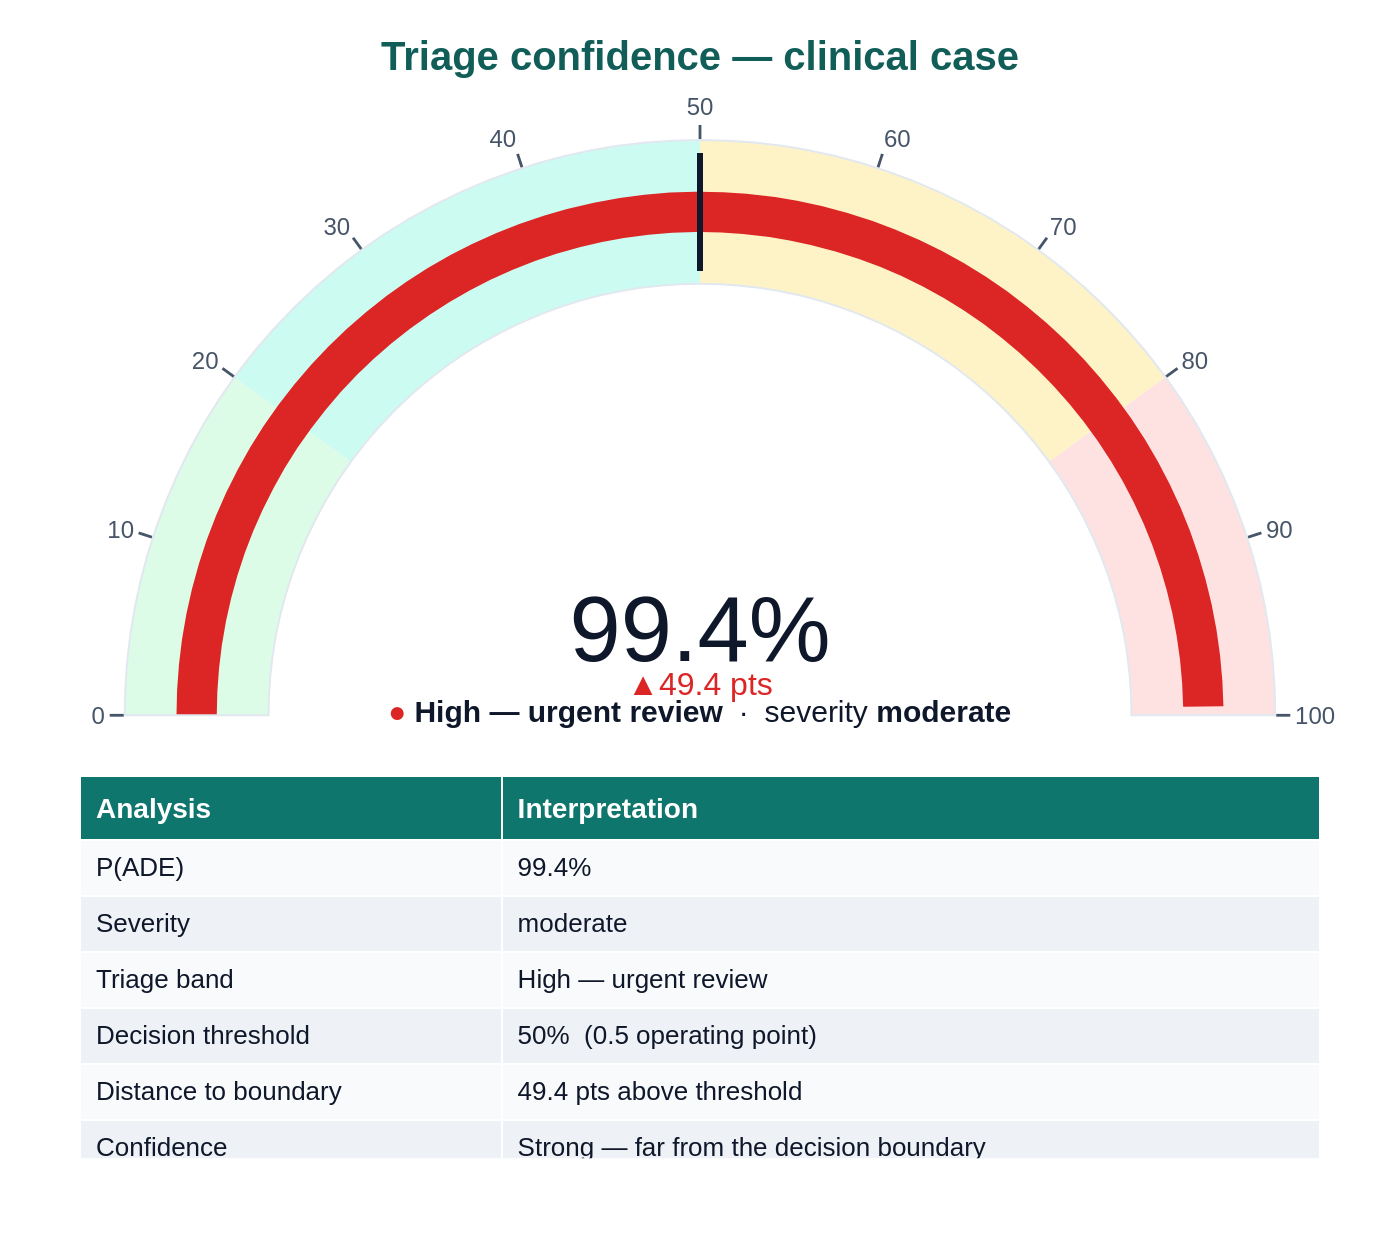

In [ ]:
proba = biobert.classify_fn(triage_case)
severity = severity_fn(triage_case)
print(f'BioBERT P(ADE) = {proba:.3f} | severity = {severity}')

xv.triage_gauge(proba, severity, 'Triage confidence — clinical case').show()


### LIME and SHAP on the case


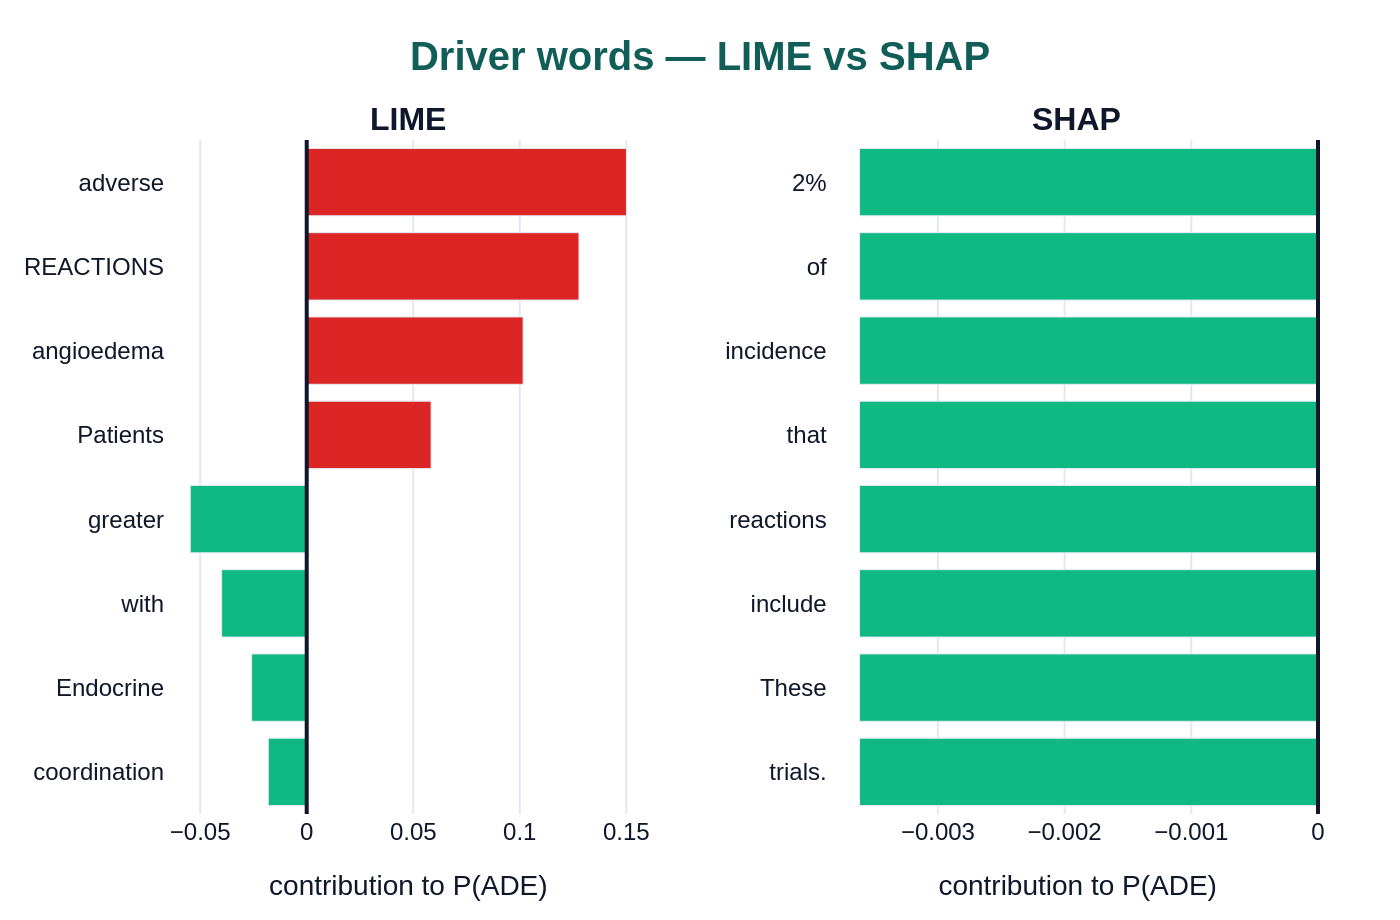

In [ ]:
lime_case = ex.explain_with_lime(
    triage_case, biobert.predict_proba, num_features=8, num_samples=200)
shap_case = ex.shap_top_words_for_text(
    triage_case, biobert.predict_proba, top_k=8, max_evals=120)

xv.lime_vs_shap(lime_case, shap_case).show()


###  Agreement between the two methods
A high overlap means LIME and SHAP point to the same driver words ; evidence the
model is using consistent, clinically meaningful signal.


LIME/SHAP top-word agreement: 0%


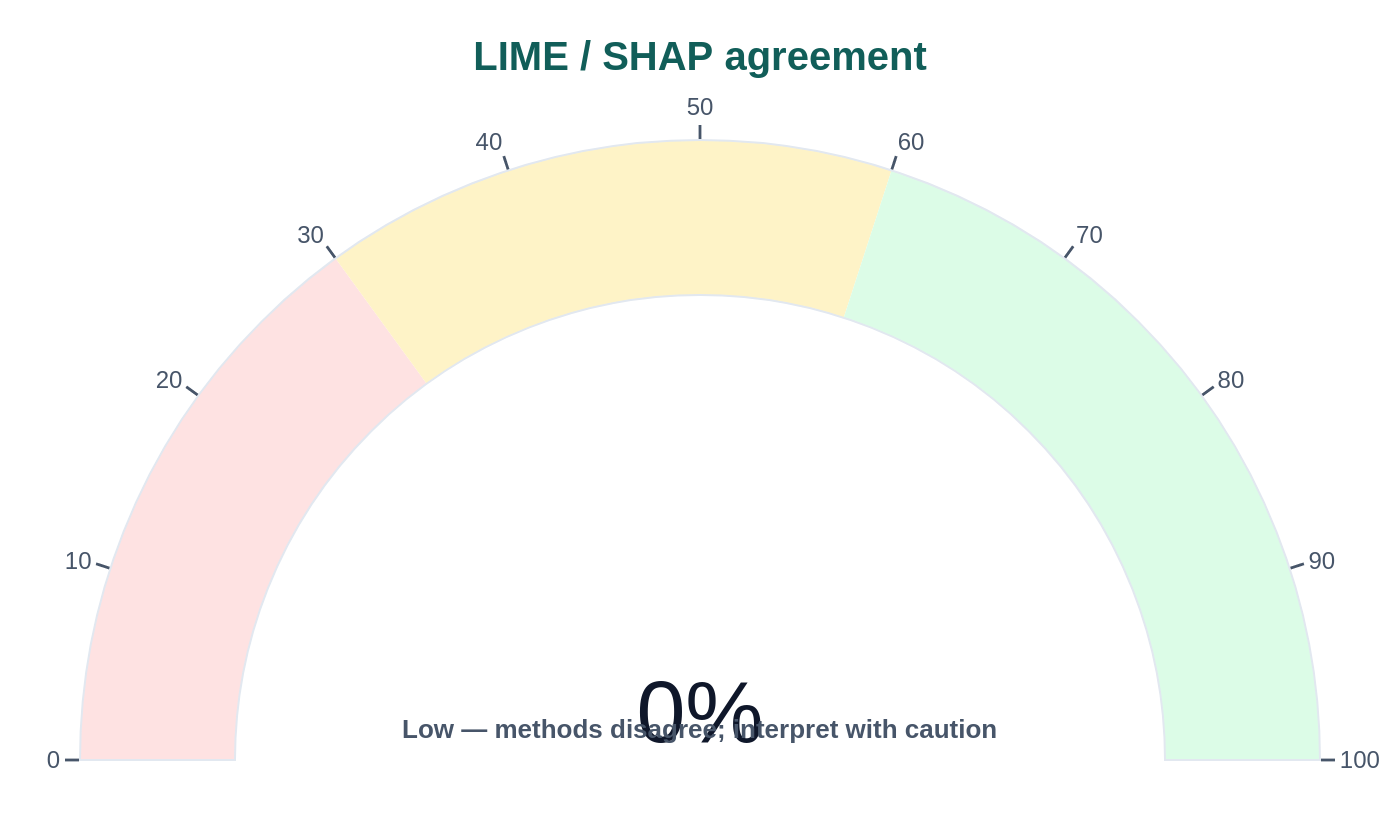

In [ ]:
from ade_agent import _explanations_agree
agreement = _explanations_agree(lime_case, shap_case) or 0.0
print(f'LIME/SHAP top-word agreement: {agreement:.0%}')
xv.agreement_indicator(agreement).show()


### Token heatmap

we used on exxample for the research to show the token heatmap

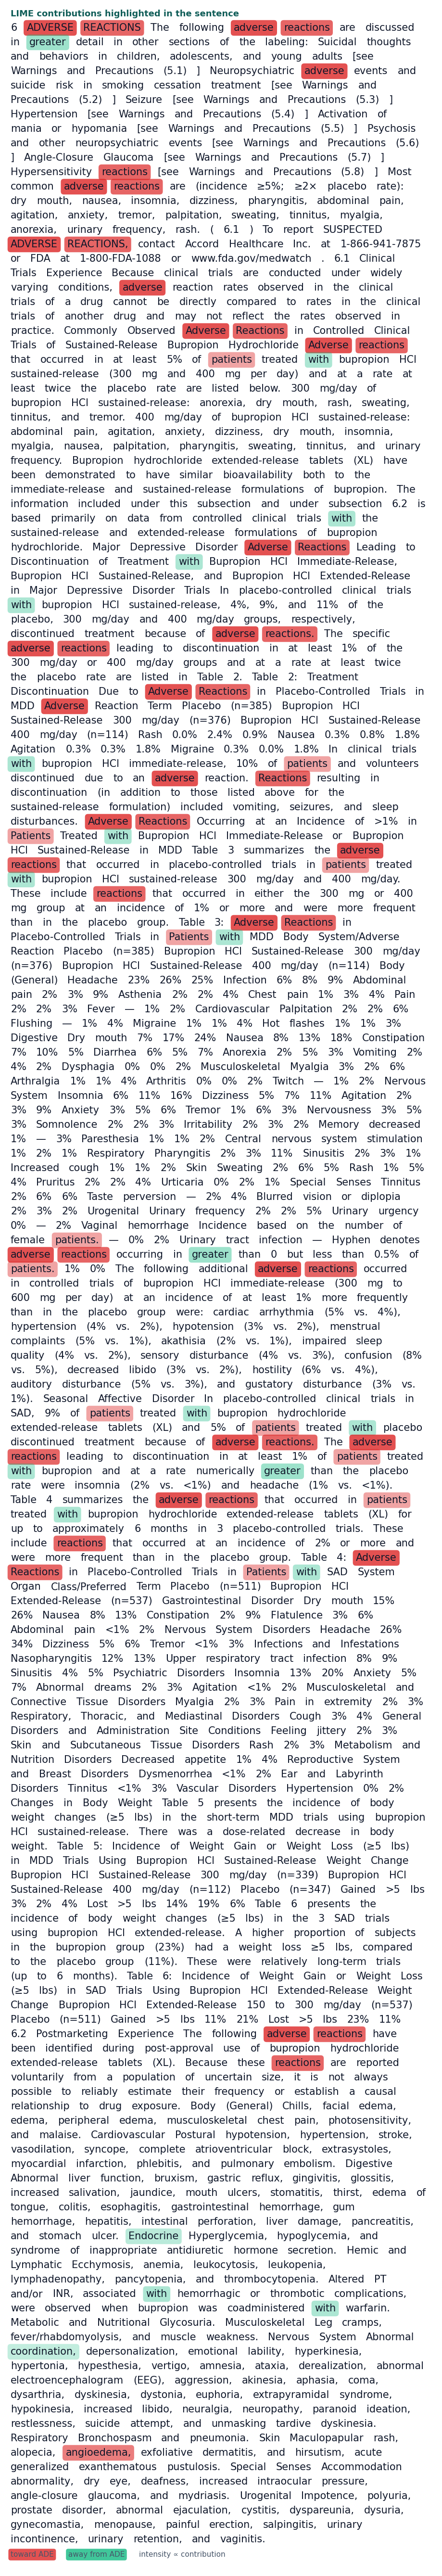

In [ ]:
xv.highlight_tokens_png(
    lime_case, text=triage_case,
    title='LIME contributions highlighted in the sentence')


### FAISS — similar known cases (precedent)


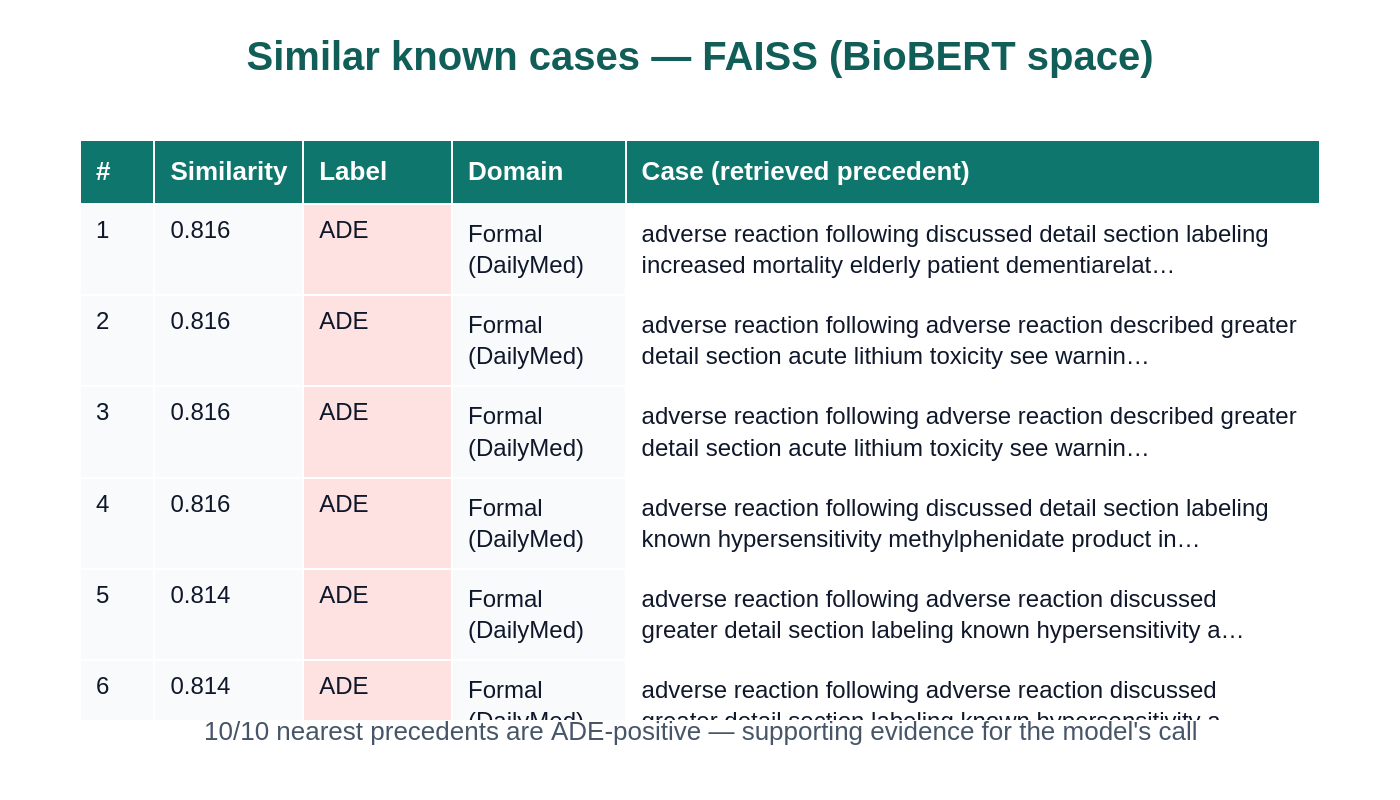

In [ ]:
neighbours = retriever.query(triage_case, k=10)
xv.similar_cases_table(neighbours).show()


###  The agent's full decision on this case


In [ ]:
result = agent.run(triage_case)
print(ag.format_trace(result))


AGENT DECISION: ADE p=0.99 | severity=moderate | moderate -> human_review
Rationale: Predicted moderate severity — escalated for clinician.

Reasoning trace:
  [1] THINK: I must first estimate ADE probability with the model.
      ACT:   classify(6 ADVERSE REACTIONS The following adverse reaction...)
      OBS:   0.9944414496421814
  [2] THINK: Model is confident; no extra retrieval needed for the decision.
      ACT:   skip_retrieval(None)
      OBS:   confident
  [3] THINK: Assess severity to inform triage routing.
      ACT:   assess_severity(6 ADVERSE REACTIONS The following adverse reaction...)
      OBS:   moderate
  [4] THINK: Prediction is positive or uncertain; running LIME and SHAP together to justify it for the human reviewer.
      ACT:   explain (LIME + SHAP)(6 ADVERSE REACTIONS The following adverse reaction...)
      OBS:   {'lime_top_words': [(np.str_('Pharyngitis'), -0.14074975638091752), (np.str_('Body'), 0.13805276608086384), (np.str_('A'
  [5] THINK: Combine probabi

###  Export the visuals


In [ ]:
fig = xv.lime_vs_shap(lime_case, shap_case)
fig.write_image('lime_vs_shap_clinical_case.png', scale=2)  # static, GitHub-safe
print('Saved lime_vs_shap_clinical_case.png')


Saved lime_vs_shap_clinical_case.png


---
##  Cross-domain explanation comparison

Our research question is about **cross-domain generalisation**: how a model trained
on formal regulatory text performs on informal patient text. This section uses
explainability to investigate *why* a gap exists: **does the model rely on different
driver words in the formal vs the informal domain?**

If the important words differ systematically across domains, that is a mechanistic
Explanation for the cross-domain performance gap: the model has learned
domain-specific vocabulary rather than transferable adverse-event concepts.


### Pick one formal and one informal ADE case
We select a positive (ADE) case from each domain so the explanations are
meaningful and directly comparable.


In [ ]:
import xai_visuals as xv
import eval_utils as ev

# ADE-positive cases from each domain
formal_pool = test_df[(test_df[ev.LABEL_COL] == 1) &
                      (test_df[ev.DOMAIN_COL].str.contains('Formal', case=False, na=False))]
informal_pool = test_df[(test_df[ev.LABEL_COL] == 1) &
                        (test_df[ev.DOMAIN_COL].str.contains('Informal', case=False, na=False))]

# random_state fixed so the report figure is reproducible; set to None for fresh picks
formal_case = formal_pool.sample(1, random_state=42).iloc[0][ev.RAW_TEXT_COL]
informal_case = informal_pool.sample(1, random_state=42).iloc[0][ev.RAW_TEXT_COL]

print('FORMAL (DailyMed):\n', formal_case[:300], '\n')
print('INFORMAL (CADEC):\n', informal_case[:300])


FORMAL (DailyMed):
 6 ADVERSE REACTIONS The following adverse reactions are discussed in greater detail in other sections of the labeling: Suicidal thoughts and behaviors in children, adolescents, and young adults [see Warnings and Precautions (5.1) ] Neuropsychiatric adverse events and suicide risk in smoking cessatio 

INFORMAL (CADEC):
 Aches and pain from head to toe, very grouchy.
I have been competitive in road racing for almost 20 years, but after starting this drug I began to notice my performance falling off.
Later I got pains so bad that I could not run.
I stopped taking this drug and after about 3 months am almost back wher


### Explain both with BioBERT (LIME)
We run the *same model* on both, so any difference in driver words reflects the
text domain, not a different model.


In [ ]:
formal_words = ex.explain_with_lime(
    formal_case, biobert.predict_proba, num_features=8, num_samples=200)
informal_words = ex.explain_with_lime(
    informal_case, biobert.predict_proba, num_features=8, num_samples=200)

print('Formal drivers  :', [w for w, _ in formal_words])
print('Informal drivers:', [w for w, _ in informal_words])


Formal drivers  : [np.str_('adverse'), np.str_('ADVERSE'), np.str_('volunteers'), np.str_('restlessness'), np.str_('during'), np.str_('Seizure'), np.str_('groups'), np.str_('FDA')]
Informal drivers: [np.str_('grouchy'), np.str_('my'), np.str_('was'), np.str_('about'), np.str_('bad'), np.str_('pain'), np.str_('and'), np.str_('stop')]


###  Side-by-side driver comparison (interactive)


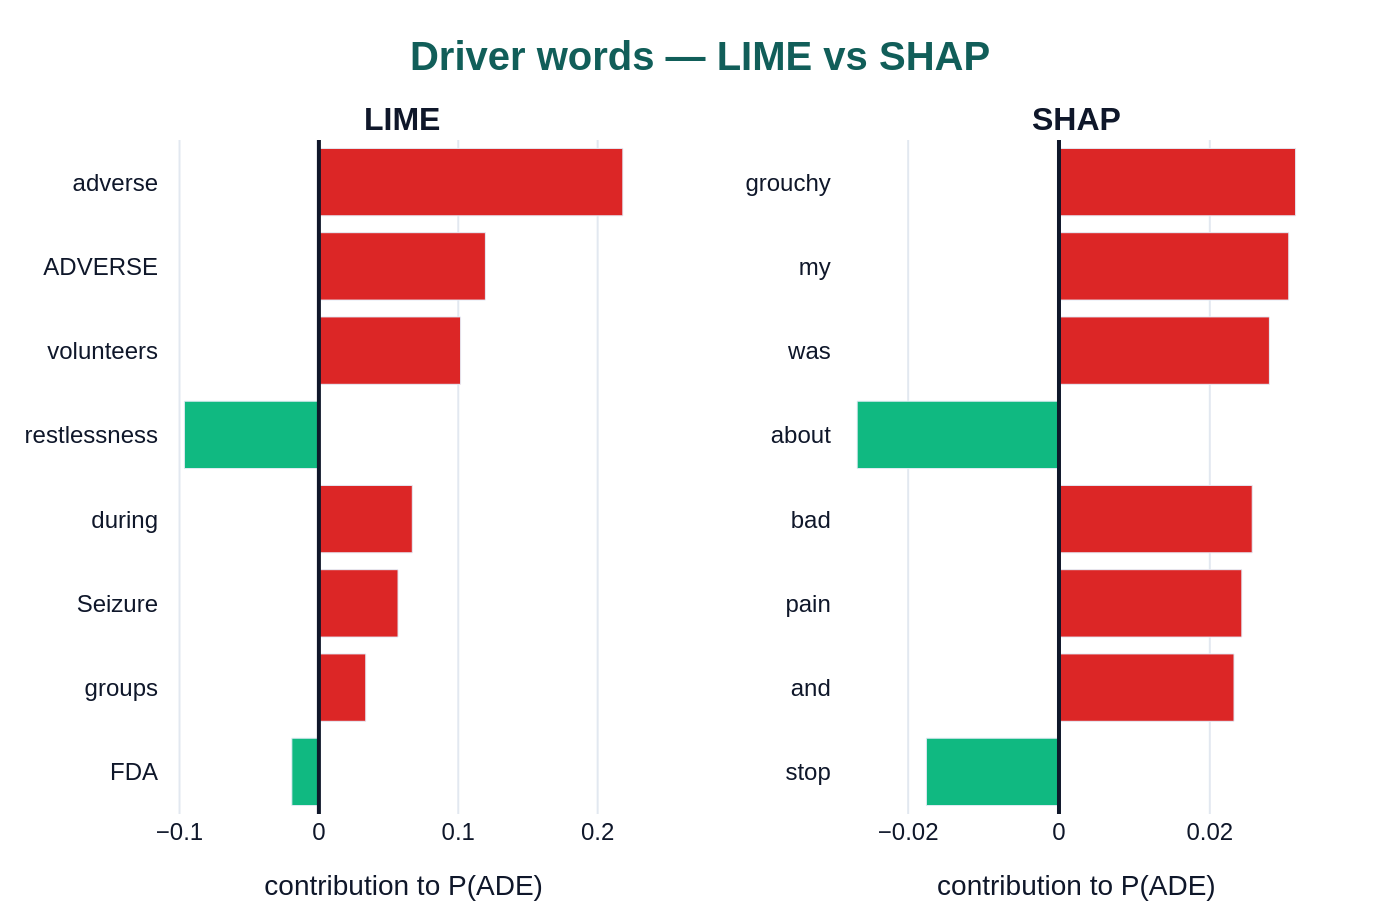

In [ ]:
xv.lime_vs_shap(formal_words, informal_words).show()

###  Quantify the vocabulary overlap
How much do the two domains' top driver words actually overlap? Low overlap is
direct evidence the model uses domain-specific vocabulary.


In [ ]:
formal_set = {w.lower() for w, _ in formal_words}
informal_set = {w.lower() for w, _ in informal_words}
shared = formal_set & informal_set
overlap = len(shared) / len(formal_set | informal_set) if (formal_set | informal_set) else 0

print(f'Shared driver words : {shared or "(none)"}')
print(f'Overlap fraction    : {overlap:.0%}')
print()
if overlap < 0.3:
    print('Low overlap ; the model relies on largely DIFFERENT vocabulary per domain,')
    print('which helps explain the cross-domain performance gap.')
else:
    print('Substantial overlap ; the model shares vocabulary across domains,')
    print('suggesting more transferable features.')


Shared driver words : (none)
Overlap fraction    : 0%

Low overlap ; the model relies on largely DIFFERENT vocabulary per domain,
which helps explain the cross-domain performance gap.
